# Customer Churn Analysis and Prediction

Customer churn is a major challenge for subscription-based businesses. Identifying customers who are likely to leave helps companies implement targeted retention strategies.

This project analyzes customer behavior and builds machine learning models to predict churn.

In [2]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



## Dataset Description

The dataset contains customer demographic information, service usage details, billing data, and customer satisfaction scores.

The target variable is **Churn**, which indicates whether a customer has left the company.

In [3]:
df=pd.read_csv(r"G:\Projects\Project-2 Customer Churn Analysis\data\TelcoCustomerChurn.csv")

In [4]:
df.head()


,CustomerID,Gender,Age,Under30,SeniorCitizen,Married,Dependents,NumberofDependents,Country,State,...,TotalExtraDataCharges,TotalLongDistanceCharges,TotalRevenue,SatisfactionScore,CustomerStatus,ChurnLabel,ChurnScore,CLTV,ChurnCategory,ChurnReason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [5]:
df.shape

(7043, 50)

In [6]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Under30', 'SeniorCitizen', 'Married',
       'Dependents', 'NumberofDependents', 'Country', 'State', 'City',
       'ZipCode', 'Latitude', 'Longitude', 'Population', 'Quarter',
       'ReferredaFriend', 'Number_of_Referrals', 'TenureinMonths', 'Offer',
       'PhoneService', 'AvgMonthlyLongDistanceCharges', 'MultipleLines',
       'InternetService', 'InternetType', 'AvgMonthlyGBDownload',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtectionPlan',
       'PremiumTechSupport', 'StreamingTV', 'StreamingMovies',
       'StreamingMusic', 'UnlimitedData', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharge', 'TotalCharges', 'TotalRefunds',
       'TotalExtraDataCharges', 'TotalLongDistanceCharges', 'TotalRevenue',
       'SatisfactionScore', 'CustomerStatus', 'ChurnLabel', 'ChurnScore',
       'CLTV', 'ChurnCategory', 'ChurnReason'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   CustomerID                     7043 non-null   object 
 1   Gender                         7043 non-null   object 
 2   Age                            7043 non-null   int64  
 3   Under30                        7043 non-null   object 
 4   SeniorCitizen                  7043 non-null   object 
 5   Married                        7043 non-null   object 
 6   Dependents                     7043 non-null   object 
 7   NumberofDependents             7043 non-null   int64  
 8   Country                        7043 non-null   object 
 9   State                          7043 non-null   object 
 10  City                           7043 non-null   object 
 11  ZipCode                        7043 non-null   int64  
 12  Latitude                       7043 non-null   f

## Data Cleaning

The dataset was cleaned by removing irrelevant columns and handling missing values. The churn label was converted into a binary variable to prepare the data for modeling.

In [8]:
df.isnull().sum()

CustomerID                          0
Gender                              0
Age                                 0
Under30                             0
SeniorCitizen                       0
Married                             0
Dependents                          0
NumberofDependents                  0
Country                             0
State                               0
City                                0
ZipCode                             0
Latitude                            0
Longitude                           0
Population                          0
Quarter                             0
ReferredaFriend                     0
Number_of_Referrals                 0
TenureinMonths                      0
Offer                            3877
PhoneService                        0
AvgMonthlyLongDistanceCharges       0
MultipleLines                       0
InternetService                     0
InternetType                     1526
AvgMonthlyGBDownload                0
OnlineSecuri

In [9]:
df["ChurnLabel"].value_counts(normalize=True)*100

ChurnLabel
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

C:\Users\Acer\AppData\Local\Temp\ipykernel_31700\374542710.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="ChurnLabel", data=df, palette="Set2")


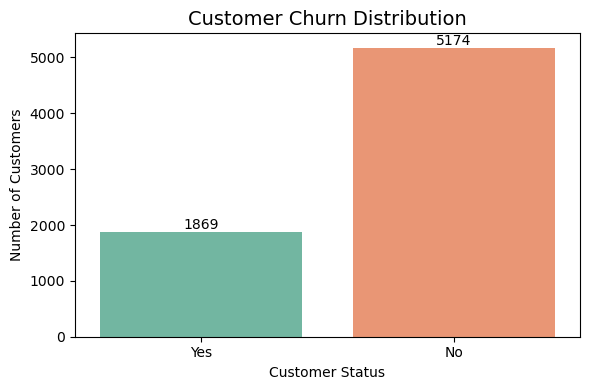

This visualization shows the overall distribution of churned and retained customers in the dataset. A smaller portion of customers have churned compared to those who remained, indicating that churn occurs in a minority of cases but still represents a significant business concern.


In [10]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x="ChurnLabel", data=df, palette="Set2")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.title("Customer Churn Distribution", fontsize=14)
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("../images/churn_distribution.png", bbox_inches="tight")
plt.show()
print("This visualization shows the overall distribution of churned and retained customers in the dataset. A smaller portion of customers have churned compared to those who remained, indicating that churn occurs in a minority of cases but still represents a significant business concern.")

### Customer Churn Distribution

This visualization shows the overall distribution of churned and retained customers in the dataset. A smaller portion of customers have churned compared to those who remained, indicating that churn occurs in a minority of cases but still represents a significant business concern.

In [11]:
df=df.drop(columns=[
    "CustomerID",
    "Country",
    "State",
    "City",
    "ZipCode",
    "Latitude",
    "Longitude",
    "Population",
    "CustomerStatus",
    "ChurnScore",
    "ChurnCategory",
    "ChurnReason"])

In [12]:
df.shape

(7043, 38)

In [13]:
df.columns

Index(['Gender', 'Age', 'Under30', 'SeniorCitizen', 'Married', 'Dependents',
       'NumberofDependents', 'Quarter', 'ReferredaFriend',
       'Number_of_Referrals', 'TenureinMonths', 'Offer', 'PhoneService',
       'AvgMonthlyLongDistanceCharges', 'MultipleLines', 'InternetService',
       'InternetType', 'AvgMonthlyGBDownload', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtectionPlan', 'PremiumTechSupport',
       'StreamingTV', 'StreamingMovies', 'StreamingMusic', 'UnlimitedData',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharge',
       'TotalCharges', 'TotalRefunds', 'TotalExtraDataCharges',
       'TotalLongDistanceCharges', 'TotalRevenue', 'SatisfactionScore',
       'ChurnLabel', 'CLTV'],
      dtype='object')

In [14]:
df["Churn"]=df["ChurnLabel"].map({"Yes":1,"No":0})

In [15]:
df[["ChurnLabel","Churn"]].head()

,ChurnLabel,Churn
0,Yes,1
1,Yes,1
2,Yes,1
3,Yes,1
4,Yes,1


## Exploratory Data Analysis

EDA was performed to understand patterns and relationships in the dataset. Various visualizations were created to analyze customer demographics, contract types, pricing, and service usage.

# Churn by Gender

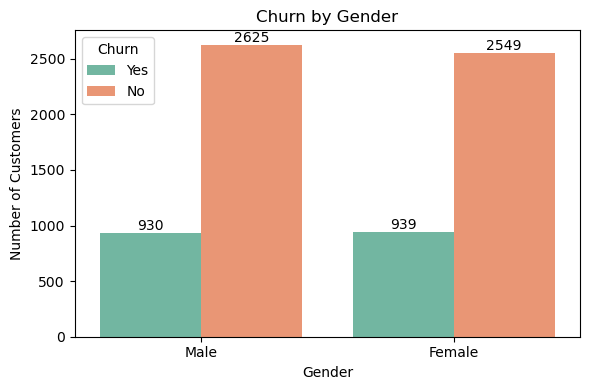

This plot compares churn distribution between male and female customers. The churn pattern appears relatively balanced across genders, suggesting that gender alone is not a strong predictor of customer churn.


In [16]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x="Gender", hue="ChurnLabel", data=df, palette="Set2")
for p in ax.patches:
    height=p.get_height()
    if height>0:
        ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.title("Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")
plt.tight_layout()
plt.show()
print("This plot compares churn distribution between male and female customers. The churn pattern appears relatively balanced across genders, suggesting that gender alone is not a strong predictor of customer churn.")

# Churn by Senior Citizen

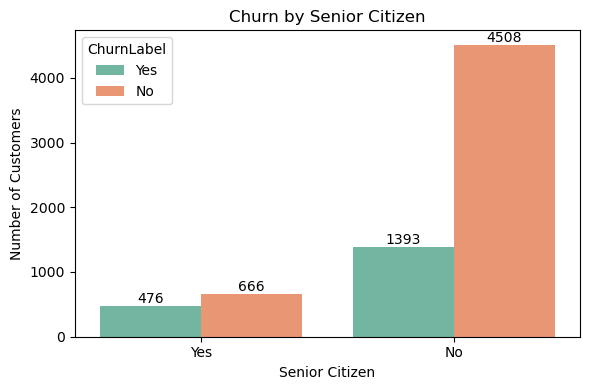

This visualization examines how churn varies between senior citizens and non-senior customers. Differences in churn behavior between these groups may indicate that age-related factors influence customer retention.


In [17]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x="SeniorCitizen", hue="ChurnLabel", data=df, palette="Set2")
for p in ax.patches:
    height = p.get_height()
    if height>0:
        ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.title("Churn by Senior Citizen")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()
print("This visualization examines how churn varies between senior citizens and non-senior customers. Differences in churn behavior between these groups may indicate that age-related factors influence customer retention.")

# Churn by Contract Type

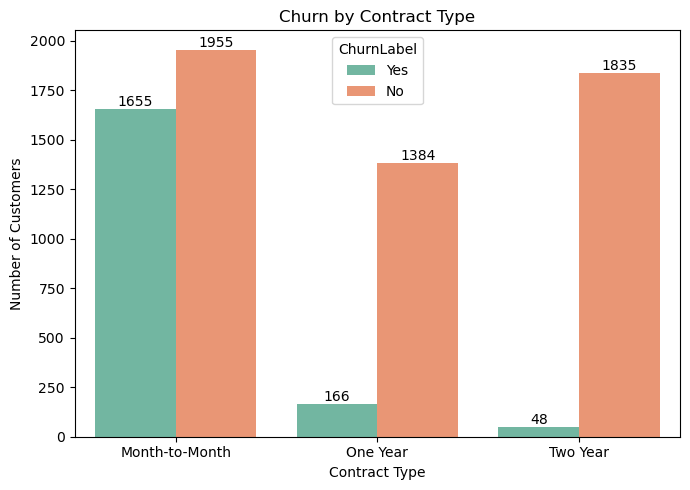

This plot analyzes churn behavior across different contract types. Customers with month-to-month contracts tend to show significantly higher churn compared to those with longer-term contracts, suggesting that longer commitments help improve customer retention.


In [18]:
plt.figure(figsize=(7,5))
ax = sns.countplot(x="Contract", hue="ChurnLabel", data=df, palette="Set2")
for p in ax.patches:
    height=p.get_height()
    if height>0:
        ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("../images/churn_by_contract.png", bbox_inches="tight")
plt.show()
print("This plot analyzes churn behavior across different contract types. Customers with month-to-month contracts tend to show significantly higher churn compared to those with longer-term contracts, suggesting that longer commitments help improve customer retention.")

# Churn by Payment Method

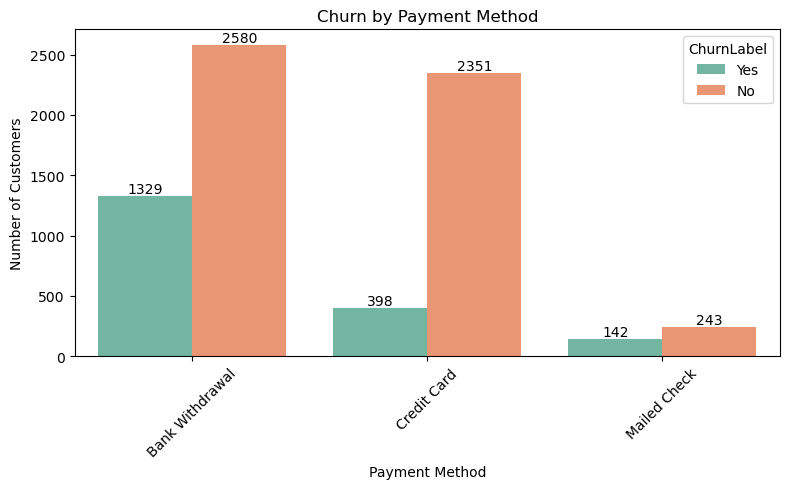

This visualization explores how different payment methods relate to churn behavior. Certain payment methods appear to be associated with higher churn rates, which may reflect differences in billing convenience or customer preferences.


In [19]:
plt.figure(figsize=(8,5))
ax = sns.countplot(x="PaymentMethod", hue="ChurnLabel", data=df, palette="Set2")
for p in ax.patches:
    height=p.get_height()
    if height>0:
        ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.xticks(rotation=45)
plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()
print("This visualization explores how different payment methods relate to churn behavior. Certain payment methods appear to be associated with higher churn rates, which may reflect differences in billing convenience or customer preferences.")

# Tenure vs Churn

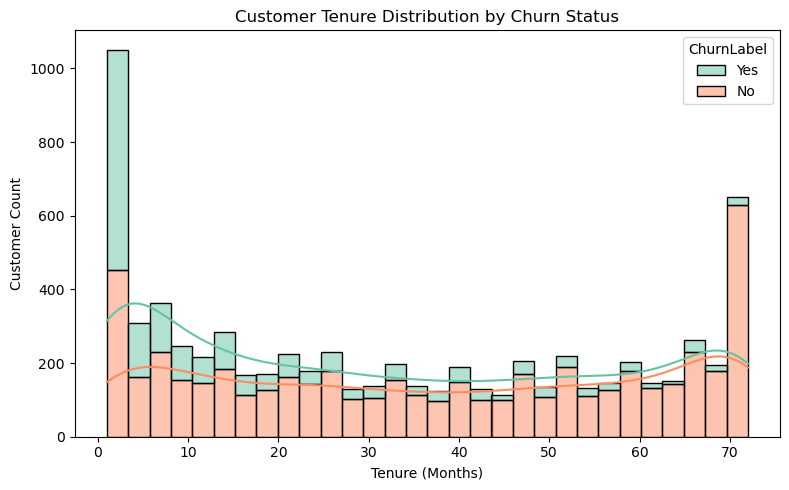

This histogram shows how customer tenure differs between churned and retained customers. Customers who churn tend to have shorter tenure, indicating that the risk of churn is higher during the early stages of the customer lifecycle.


In [20]:
plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x="TenureinMonths",
    hue="ChurnLabel",
    bins=30,
    kde=True,
    palette="Set2",
    multiple="stack")
plt.title("Customer Tenure Distribution by Churn Status")
plt.xlabel("Tenure (Months)")
plt.ylabel("Customer Count")
plt.tight_layout()
plt.savefig("../images/tenure_distribution.png", bbox_inches="tight")
plt.show()
print("This histogram shows how customer tenure differs between churned and retained customers. Customers who churn tend to have shorter tenure, indicating that the risk of churn is higher during the early stages of the customer lifecycle.")

# Monthly Charges vs Churn

C:\Users\Acer\AppData\Local\Temp\ipykernel_31700\414484059.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


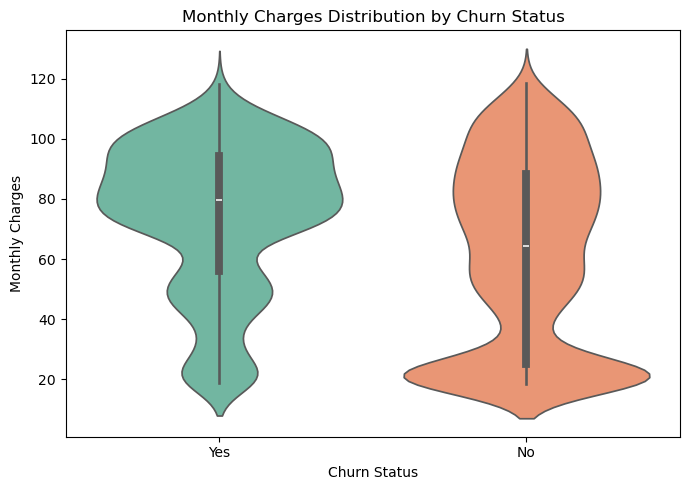

This plot compares the distribution of monthly service charges between churned and retained customers. Customers paying higher monthly charges appear more likely to churn, suggesting that pricing may influence customer satisfaction and retention.


In [21]:
plt.figure(figsize=(7,5))
sns.violinplot(
    x="ChurnLabel",
    y="MonthlyCharge",
    data=df,
    palette="Set2")
plt.title("Monthly Charges Distribution by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.savefig("../images/monthly_charges_vs_churn.png", bbox_inches="tight")
plt.show()
print("This plot compares the distribution of monthly service charges between churned and retained customers. Customers paying higher monthly charges appear more likely to churn, suggesting that pricing may influence customer satisfaction and retention.")

# Satisfaction Score vs Churn

C:\Users\Acer\AppData\Local\Temp\ipykernel_31700\1305808881.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


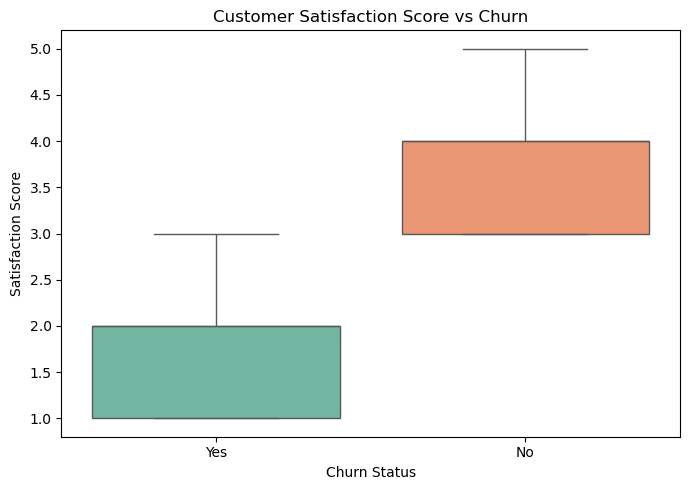

In [22]:
plt.figure(figsize=(7,5))
sns.boxplot(
    x="ChurnLabel",
    y="SatisfactionScore",
    data=df,
    palette="Set2")
plt.title("Customer Satisfaction Score vs Churn")
plt.xlabel("Churn Status")
plt.ylabel("Satisfaction Score")
plt.tight_layout()
plt.show()

# Internet Service vs Churn

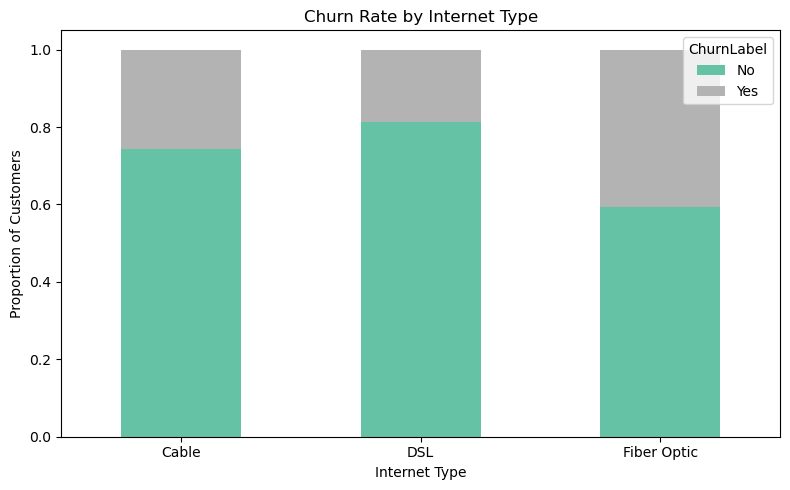

In [23]:
internet_churn = pd.crosstab(
    df["InternetType"],
    df["ChurnLabel"],
    normalize="index")
internet_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    colormap="Set2")
plt.title("Churn Rate by Internet Type")
plt.xlabel("Internet Type")
plt.ylabel("Proportion of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# CLTV vs Churn

C:\Users\Acer\AppData\Local\Temp\ipykernel_31700\422795450.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


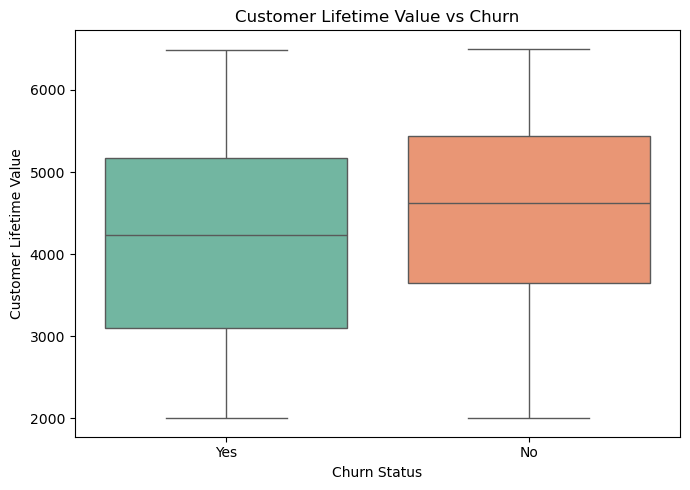

This boxplot compares the customer lifetime value (CLTV) between churned and retained customers. Customers who remain with the company generally have higher lifetime value, highlighting the financial impact of customer retention.


In [24]:
plt.figure(figsize=(7,5))
sns.boxplot(
    x="ChurnLabel",
    y="CLTV",
    data=df,
    palette="Set2")
plt.title("Customer Lifetime Value vs Churn")
plt.xlabel("Churn Status")
plt.ylabel("Customer Lifetime Value")
plt.tight_layout()
plt.savefig("../images/cltv_vs_churn.png", bbox_inches="tight")
plt.show()
print("This boxplot compares the customer lifetime value (CLTV) between churned and retained customers. Customers who remain with the company generally have higher lifetime value, highlighting the financial impact of customer retention.")

## Correlation Analysis

A correlation heatmap was used to examine relationships between numerical variables and identify potential predictors of customer churn.

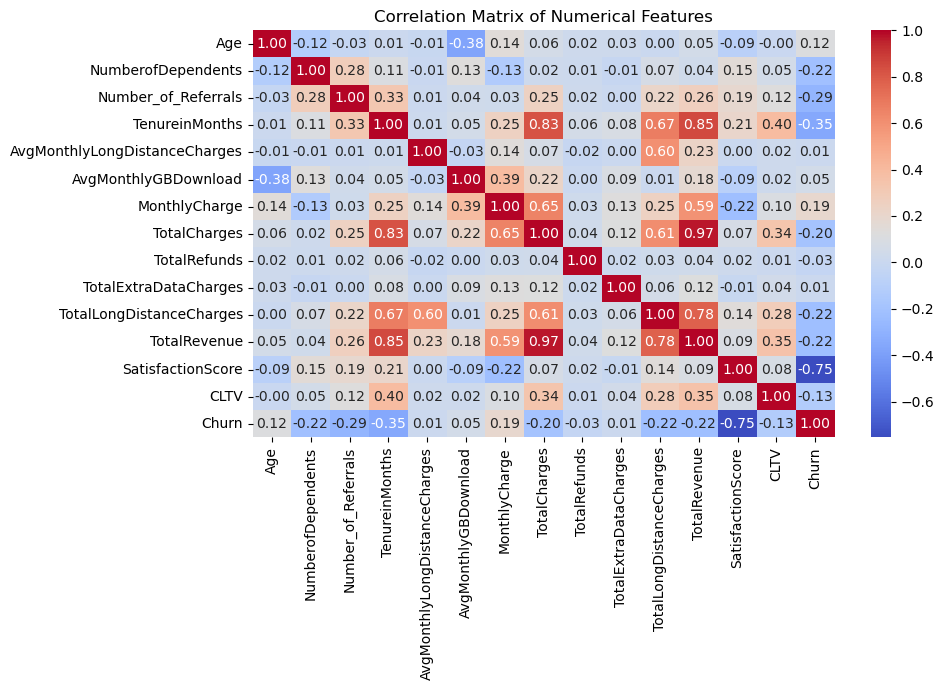

In [25]:
plt.figure(figsize=(10,7))
corr = df.corr(numeric_only=True)
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

# Feature Engineering

In [26]:
# Create Tenure Groups
df["TenureGroup"] = pd.cut(
    df["TenureinMonths"],
    bins=[0,12,24,48,72],
    labels=["0-12 Months","12-24 Months","24-48 Months","48+ Months"])

In [27]:
# Create Spending Segments
df["SpendingGroup"] = pd.qcut(
    df["MonthlyCharge"],
    q=3,
    labels=["Low","Medium","High"])

# Preparing Data for Machine Learning

In [28]:
X = df.drop(["Churn","ChurnLabel"], axis=1)
y = df["Churn"]

In [29]:
X = pd.get_dummies(X, drop_first=True)

In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Machine Learning Models

Two models were trained to predict customer churn:

Logistic Regression and
Random Forest

The models were evaluated using accuracy, precision, recall, and F1-score.

# Logistic Regression

In [31]:
from sklearn.linear_model import LogisticRegression
log_model=LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

C:\Users\Acer\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [32]:
y_pred=log_model.predict(X_test)

In [33]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[984  25]
 [ 70 330]]
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      1009
           1       0.93      0.82      0.87       400

    accuracy                           0.93      1409
   macro avg       0.93      0.90      0.91      1409
weighted avg       0.93      0.93      0.93      1409



# Random Forest

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [35]:
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

[[1001    8]
 [  61  339]]
              precision    recall  f1-score   support

           0       0.94      0.99      0.97      1009
           1       0.98      0.85      0.91       400

    accuracy                           0.95      1409
   macro avg       0.96      0.92      0.94      1409
weighted avg       0.95      0.95      0.95      1409



## Model Comparison

The Random Forest model achieved higher performance compared to Logistic Regression, demonstrating better ability to identify customers at risk of churn.

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred)],
    
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred)],
    
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred)],
    
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred)]
})

comparison.round(2)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.93,0.93,0.82,0.87
1,Random Forest,0.95,0.98,0.85,0.91


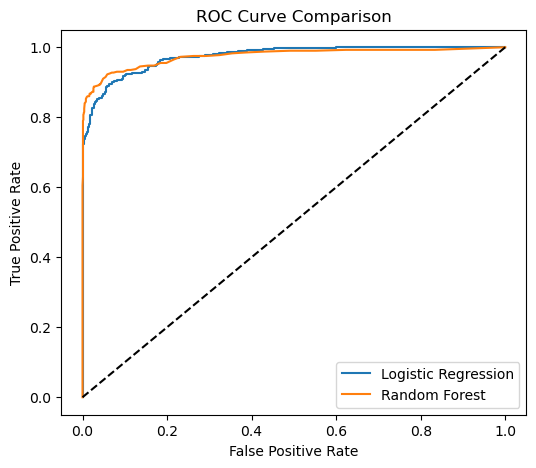

In [37]:
from sklearn.metrics import roc_curve, auc

log_probs = log_model.predict_proba(X_test)[:,1]
rf_probs = rf_model.predict_proba(X_test)[:,1]

log_fpr, log_tpr, _ = roc_curve(y_test, log_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

plt.figure(figsize=(6,5))

plt.plot(log_fpr, log_tpr, label="Logistic Regression")
plt.plot(rf_fpr, rf_tpr, label="Random Forest")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

## Key Insights

- Customer satisfaction is the strongest predictor of churn
- Customers with shorter tenure are more likely to churn
- Higher monthly charges increase churn probability
- Long-term contracts significantly reduce churn

In [38]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.head(10)

SatisfactionScore           0.449579
TenureinMonths              0.047499
MonthlyCharge               0.040819
Contract_Two Year           0.038037
TotalRevenue                0.038029
TotalCharges                0.037013
Number_of_Referrals         0.033206
TotalLongDistanceCharges    0.029876
AvgMonthlyGBDownload        0.024457
Age                         0.024333
dtype: float64

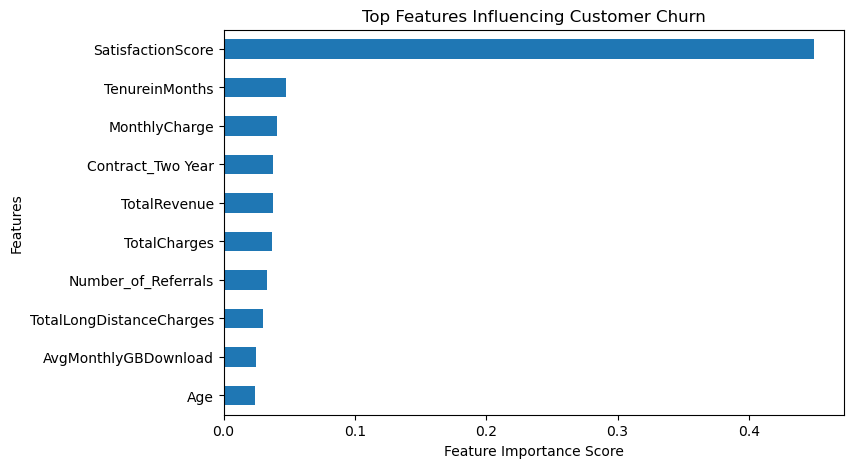

Feature importance analysis reveals which variables contribute the most to predicting customer churn. Customer satisfaction score emerges as the most influential feature, followed by factors such as tenure, monthly charges, and contract type.


In [39]:
importance.head(10).sort_values().plot(
    kind="barh",
    figsize=(8,5),
    title="Top Features Influencing Customer Churn",
    xlabel="Feature Importance Score",
    ylabel="Features"
)
plt.savefig("../images/feature_importance.png", bbox_inches="tight")
plt.show()
print("Feature importance analysis reveals which variables contribute the most to predicting customer churn. Customer satisfaction score emerges as the most influential feature, followed by factors such as tenure, monthly charges, and contract type.")


## Business Recommendations

Based on the analysis, companies should focus on improving customer satisfaction, strengthening early customer engagement, and encouraging long-term contracts to reduce churn.

## Conclusion

This project analyzed customer churn using exploratory data analysis and machine learning techniques.

The Random Forest model achieved the best performance, reaching approximately 95% accuracy in predicting churn.

The analysis revealed that customer satisfaction, tenure, pricing, and contract type are the strongest drivers of churn. These insights can help businesses implement targeted retention strategies and reduce customer attrition.

In [42]:
df.to_csv("cleaned_churn_data.csv", index=False)